# Pipeline Completo de Pesquisa - Reprodutibilidade de Notebooks Jupyter

Este notebook master automatiza todo o workflow da pesquisa para facilitar re-execuções. O pipeline pode usar dados já coletados ou fazer nova coleta, respondendo às 4 questões:

1. **RQ1**: Qual a taxa de reprodutibilidade de notebooks Jupyter no GitHub em 2025?
2. **RQ2**: As más práticas identificadas por outros artigos relacionados ainda prevalecem?
3. **RQ3**: Quais fatores mais impactam a reprodutibilidade hoje?
4. **RQ4**: Como a IA influencia a qualidade e reprodutibilidade?

---

## Arquitetura do Pipeline

- **Etapa 0**: Configuração Global
- **Etapa 1**: Validação de Ambiente
- **Etapa 2**: Obtenção de Dados de Coleta
- **Etapa 3**: Execução de Notebooks
- **Etapa 4**: Sumarização Descritiva
- **Etapa 5**: Análises por Questão de Pesquisa (RQ1-4)
- **Etapa 6**: Relatório Final Consolidado


In [43]:
# === ETAPA 0: CONFIGURAÇÃO GLOBAL ===

import os
import sys
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Configuração de plotagem
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Seeds para reprodutibilidade
np.random.seed(42)

print("✓ Imports carregados com sucesso")
print(f"Python version: {sys.version}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✓ Imports carregados com sucesso
Python version: 3.13.3 (main, Apr  9 2025, 04:03:52) [Clang 20.1.0 ]
Pandas version: 2.3.3
NumPy version: 2.3.4


## Configuração de Parâmetros

Configure o modo de operação do pipeline:


In [ ]:
# ========== CONFIGURAÇÃO DO PIPELINE ==========

# 🔧 CONFIGURAÇÃO DE PATHS

DATA_ROOT = Path("/home/asu/reproducibility_of_jupyter_notebooks-1/data")

# MODO DE OPERAÇÃO (escolha apenas um)
MODE = "use_existing"  # Opções: "use_existing", "collect_new", "reexecute_existing"

# FIXAR RUN_DIR (deixe None para criar novo, ou especifique timestamp existente)
# Exemplo: "20251028_144659" para usar dados de uma execução anterior
FIXED_RUN_TIMESTAMP = "20251028_144659"  # None para criar novo, ou "YYYYMMDD_HHMMSS"

# Parâmetros configuráveis
CONFIG = {
    # Coleta
    "date_start": "2025-01-01",
    "date_end": "2025-10-28",
    "max_items": 271,
    "require_outputs": True,
    
    # Execução
    "timeout": 300,  # segundos
    "policy": "relaxed",  # "relaxed" ou "strict"
    
    # Diretório de trabalho
    "workspace_root": Path.cwd(),
    "data_dir": DATA_ROOT,
    "scripts_dir": Path("scripts"),
}

# Determinar RUN_DIR
if FIXED_RUN_TIMESTAMP:
    TIMESTAMP = FIXED_RUN_TIMESTAMP
    RUN_DIR = CONFIG["data_dir"] / f"run_{TIMESTAMP}"
    print(f"📌 Usando RUN_DIR fixo: {RUN_DIR}")
else:
    TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
    RUN_DIR = CONFIG["data_dir"] / f"run_{TIMESTAMP}"
    print(f"🆕 Criando novo RUN_DIR: {RUN_DIR}")

print(f"{'='*60}")
print("CONFIGURAÇÃO DO PIPELINE")
print(f"{'='*60}")
print(f"Modo de operação: {MODE}")
print(f"Timestamp: {TIMESTAMP}")
print(f"Diretório de trabalho: {RUN_DIR}")
print("\nParâmetros:")
for key, value in CONFIG.items():
    if key not in ["workspace_root", "data_dir", "scripts_dir"]:
        print(f"  - {key}: {value}")
print(f"{'='*60}")


📌 Usando RUN_DIR fixo: /home/asu/reproducibility_of_jupyter_notebooks-1/scripts/data/run_20251028_144659
CONFIGURAÇÃO DO PIPELINE
Modo de operação: use_existing
Timestamp: 20251028_144659
Diretório de trabalho: /home/asu/reproducibility_of_jupyter_notebooks-1/scripts/data/run_20251028_144659

Parâmetros:
  - date_start: 2025-01-01
  - date_end: 2025-10-28
  - max_items: 271
  - require_outputs: True
  - timeout: 300
  - policy: relaxed


---

## ETAPA 1: Validação de Ambiente

Verificar Python, dependências e configurar estrutura de diretórios.


In [45]:
# Validação de ambiente

print("🔍 Validando ambiente...\n")

# 1. Verificar versão do Python
python_version = sys.version_info
print(f"✓ Python version: {python_version.major}.{python_version.minor}.{python_version.micro}")
if python_version.major < 3 or (python_version.major == 3 and python_version.minor < 10):
    print("⚠️  Aviso: Recomendado Python >= 3.10")
else:
    print("  ✓ Python >= 3.10")

# 2. Verificar dependências críticas
required_modules = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scipy', 'sklearn', 'nbformat']
missing_modules = []

for module_name in required_modules:
    try:
        __import__(module_name)
        print(f"  ✓ {module_name}")
    except ImportError:
        missing_modules.append(module_name)
        print(f"  ✗ {module_name} (não encontrado)")

if missing_modules:
    print(f"\n⚠️  Módulos faltantes: {', '.join(missing_modules)}")
    print("   Instale com: pip install " + " ".join(missing_modules))
else:
    print("\n✓ Todas as dependências críticas estão instaladas")

# 3. Verificar GITHUB_TOKEN (se necessário)
if MODE == "collect_new":
    from dotenv import load_dotenv
    load_dotenv()
    github_token = os.environ.get("GITHUB_TOKEN")
    if github_token:
        print(f"✓ GITHUB_TOKEN encontrado (len={len(github_token)})")
    else:
        print("⚠️  GITHUB_TOKEN não encontrado. Necessário para coleta.")
        print("   Configure com: export GITHUB_TOKEN='seu_token'")

# 4. Criar estrutura de diretórios
if MODE in ["collect_new", "reexecute_existing"]:
    RUN_DIR.mkdir(parents=True, exist_ok=True)
    (RUN_DIR / "raw_ipynb").mkdir(exist_ok=True)
    (RUN_DIR / "figures").mkdir(exist_ok=True)
    print(f"\n✓ Diretórios criados: {RUN_DIR}")
else:
    print(f"\n✓ Modo '{MODE}': não é necessário criar novos diretórios")

# 5. Verificar existência de arquivos necessários
if MODE == "use_existing":
    notebooks_file = RUN_DIR / 'notebooks_collected.csv'
    execution_file = RUN_DIR / 'execution_results_docker.csv'
    
    if notebooks_file.exists():
        print(f"✓ Arquivo de notebooks encontrado: {notebooks_file}")
    else:
        print(f"✗ Arquivo de notebooks NÃO encontrado: {notebooks_file}")
    
    if execution_file.exists():
        print(f"✓ Arquivo de execução encontrado: {execution_file}")
    else:
        print(f"✗ Arquivo de execução NÃO encontrado: {execution_file}")

print("\n" + "="*60)
print("Validação de ambiente concluída!")
print("="*60)


🔍 Validando ambiente...

✓ Python version: 3.13.3
  ✓ Python >= 3.10
  ✓ pandas
  ✓ numpy
  ✓ matplotlib
  ✓ seaborn
  ✓ scipy
  ✓ sklearn
  ✓ nbformat

✓ Todas as dependências críticas estão instaladas

✓ Modo 'use_existing': não é necessário criar novos diretórios
✓ Arquivo de notebooks encontrado: /home/asu/reproducibility_of_jupyter_notebooks-1/scripts/data/run_20251028_144659/notebooks_collected.csv
✓ Arquivo de execução encontrado: /home/asu/reproducibility_of_jupyter_notebooks-1/scripts/data/run_20251028_144659/execution_results_docker.csv

Validação de ambiente concluída!


---

## ETAPA 2: Obtenção de Dados de Coleta

Coletar novos notebooks ou carregar dados existentes.


In [46]:
# Obtenção de dados de coleta

print("📊 Etapa 2: Obtenção de Dados de Coleta\n")

if MODE == "use_existing":
    print("Modo: Usar dados existentes")
    notebooks_path = RUN_DIR / 'notebooks_collected.csv'
    
    if not notebooks_path.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {notebooks_path}")
    
    df_notebooks = pd.read_csv(notebooks_path)
    print(f"✓ Carregados {len(df_notebooks)} notebooks de: {notebooks_path}")
    
    # Estatísticas preliminares
    print("\nEstatísticas dos dados:")
    print(f"  - Total de notebooks: {len(df_notebooks)}")
    if 'parse_ok' in df_notebooks.columns:
        print(f"  - Parsing OK: {df_notebooks['parse_ok'].sum()} ({df_notebooks['parse_ok'].mean()*100:.1f}%)")
    if 'language' in df_notebooks.columns:
        print(f"  - Linguagem Python: {(df_notebooks['language'] == 'python').sum()}")
    if 'n_code' in df_notebooks.columns:
        print(f"  - Média de células de código: {df_notebooks['n_code'].mean():.1f}")
    
elif MODE == "collect_new":
    print("Modo: Coletar novos notebooks")
    
    # Preparar comando
    collect_script =  "collect_notebooks.py"
    output_csv = RUN_DIR / "notebooks_collected.csv"
    raw_ipynb_dir = RUN_DIR / "raw_ipynb"
    
    cmd = [
        sys.executable,
        str(collect_script),
        "--date-start", CONFIG["date_start"],
        "--date-end", CONFIG["date_end"],
        "--max-items", str(CONFIG["max_items"]),
        "--output", str(output_csv),
        "--save-notebooks-dir", str(raw_ipynb_dir)
    ]
    
    if CONFIG["require_outputs"]:
        cmd.append("--require-outputs")
    
    print(f"Executando: {' '.join(cmd)}\n")
    print("⏳ Coletando notebooks do GitHub...")
    print(f"   Período: {CONFIG['date_start']} até {CONFIG['date_end']}")
    print(f"   Meta: {CONFIG['max_items']} notebooks\n")
    
    try:
        # Executar com output em tempo real
        process = subprocess.Popen(
            cmd, 
            stdout=subprocess.PIPE, 
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
            universal_newlines=True
        )
        
        # Mostrar output em tempo real
        for line in process.stdout:
            print(line, end='')
        
        process.wait()
        
        if process.returncode == 0:
            print("\n✓ Coleta concluída com sucesso!")
            
            if output_csv.exists():
                df_notebooks = pd.read_csv(output_csv)
                print(f"✓ Carregados {len(df_notebooks)} notebooks coletados")
            else:
                raise FileNotFoundError(f"Arquivo de saída não criado: {output_csv}")
        else:
            print(f"✗ Erro na coleta (código {process.returncode})")

            raise RuntimeError("Falha na coleta de notebooks")
            
    except Exception as e:
        print(f"✗ Erro ao executar script de coleta: {e}")

        raise
        
elif MODE == "reexecute_existing":
    print("Modo: Re-executar notebooks existentes")
    # Carregar a lista existente para re-execução
    notebooks_path = RUN_DIR / 'notebooks_collected.csv'
    
    if not notebooks_path.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {notebooks_path}")
    
    df_notebooks = pd.read_csv(notebooks_path)
    print(f"✓ Carregados {len(df_notebooks)} notebooks para re-execução")
    
else:
    raise ValueError(f"Modo inválido: {MODE}")

print("\n" + "="*60)
print(f"Dados de coleta prontos! Total: {len(df_notebooks)} notebooks")
print("="*60)


📊 Etapa 2: Obtenção de Dados de Coleta

Modo: Usar dados existentes
✓ Carregados 271 notebooks de: /home/asu/reproducibility_of_jupyter_notebooks-1/scripts/data/run_20251028_144659/notebooks_collected.csv

Estatísticas dos dados:
  - Total de notebooks: 271
  - Linguagem Python: 270
  - Média de células de código: 10.6

Dados de coleta prontos! Total: 271 notebooks


---

## ETAPA 3: Execução de Notebooks

Executar notebooks ou carregar resultados de execução existentes.


In [47]:
# === ANÁLISE DE VERSÕES PYTHON E SELEÇÃO DE IMAGEM DOCKER ===

if MODE == "use_existing":
    print("⏭️  Modo 'use_existing': Pulando análise de versões Python")
    print("="*60)
else:
    print("🔍 Analisando versões Python nos notebooks...")

def analyze_python_versions_from_csv(csv_path):
    """Analisa as versões Python declaradas no CSV e retorna estatísticas."""
    import csv
    versions_count = {}
    total_notebooks = 0

    try:
        with open(csv_path, 'r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            for row in reader:
                if row.get("nb_ok_parse") == "True":
                    total_notebooks += 1
                    version = row.get("python_version_declared", "").strip()
                    if version:
                        versions_count[version] = versions_count.get(version, 0) + 1
                    else:
                        versions_count["unknown"] = versions_count.get("unknown", 0) + 1
    except Exception as e:
        print(f"Erro ao analisar CSV: {e}")
    
    return {
        "versions_count": versions_count,
        "total_notebooks": total_notebooks,
        "most_common_version": max(versions_count.items(), key=lambda x: x[1])[0] if versions_count else "unknown"
    }

def suggest_docker_image(python_version):
    """Sugere a imagem Docker baseada na versão Python."""
    if not python_version or python_version == "unknown":
        return "notebook-executor"  # Python 3.10 padrão
    
    version_parts = python_version.split('.')
    major = int(version_parts[0]) if version_parts else 0
    minor = int(version_parts[1]) if len(version_parts) > 1 else 0
    
    if major == 3:
        if minor == 8:
            return "notebook-executor-python38"
        elif minor == 9:
            return "notebook-executor-python39"
        elif minor == 10:
            return "notebook-executor"
        elif minor == 11:
            return "notebook-executor-python311"
        elif minor == 12:
            return "notebook-executor-python312"
    
    return "notebook-executor"  # fallback

# Determinar input CSV
if MODE == "collect_new":
    input_csv = RUN_DIR / "notebooks_collected.csv"
else:  # reexecute_existing ou use_existing
    input_csv = RUN_DIR / "notebooks_collected.csv"

if input_csv.exists():
    # Analisar versões Python
    analysis = analyze_python_versions_from_csv(input_csv)
    most_common = analysis['most_common_version']
    suggested_image = suggest_docker_image(most_common)
    
    print(f"📊 Total de notebooks: {analysis['total_notebooks']}")
    print("📊 Versões Python encontradas:")
    
    for version, count in sorted(analysis['versions_count'].items()):
        percentage = (count / analysis['total_notebooks']) * 100 if analysis['total_notebooks'] > 0 else 0
        print(f"   - Python {version}: {count} notebooks ({percentage:.1f}%)")
    
    print(f"\n🎯 Recomendações:")
    print(f"   Versão mais comum: Python {most_common}")
    print(f"   Imagem Docker sugerida: {suggested_image}")
    
    # Atualizar configuração global
    CONFIG["docker_image"] = suggested_image
    CONFIG["python_version"] = most_common
    
    if most_common != "unknown":
        dockerfile_name = f"Dockerfile.python{most_common.replace('.', '')}"
        print(f"\n🚀 Comando para construir:")
        print(f"   docker build -t {suggested_image} -f {dockerfile_name} .")
    else:
        print(f"\n⚠️  Nenhuma versão Python declarada encontrada. Usando imagem padrão.")
        CONFIG["docker_image"] = "notebook-executor"
        CONFIG["python_version"] = "unknown"
else:
    print(f"⚠️  CSV não encontrado: {input_csv}")
    print("Usando imagem Docker padrão...")
    CONFIG["docker_image"] = "notebook-executor"
    CONFIG["python_version"] = "unknown"

print(f"\n✅ Imagem Docker selecionada: {CONFIG['docker_image']}")
print("="*60)


⏭️  Modo 'use_existing': Pulando análise de versões Python
📊 Total de notebooks: 270
📊 Versões Python encontradas:
   - Python 2.7.6: 1 notebooks (0.4%)
   - Python 3.10.10: 2 notebooks (0.7%)
   - Python 3.10.11: 34 notebooks (12.6%)
   - Python 3.10.12: 34 notebooks (12.6%)
   - Python 3.10.13: 1 notebooks (0.4%)
   - Python 3.10.14: 2 notebooks (0.7%)
   - Python 3.10.16: 1 notebooks (0.4%)
   - Python 3.10.6: 6 notebooks (2.2%)
   - Python 3.11.10: 1 notebooks (0.4%)
   - Python 3.11.11: 9 notebooks (3.3%)
   - Python 3.11.5: 5 notebooks (1.9%)
   - Python 3.11.9: 2 notebooks (0.7%)
   - Python 3.12.0: 6 notebooks (2.2%)
   - Python 3.12.1: 11 notebooks (4.1%)
   - Python 3.12.11: 1 notebooks (0.4%)
   - Python 3.12.2: 1 notebooks (0.4%)
   - Python 3.12.3: 4 notebooks (1.5%)
   - Python 3.12.4: 24 notebooks (8.9%)
   - Python 3.12.5: 5 notebooks (1.9%)
   - Python 3.12.7: 1 notebooks (0.4%)
   - Python 3.12.8: 4 notebooks (1.5%)
   - Python 3.12.9: 5 notebooks (1.9%)
   - Python 3

In [ ]:
# === EXECUÇÃO VIA DOCKER COM VERSÃO PYTHON INTELIGENTE ===

print("🐳 Etapa 3: Execução de Notebooks via Docker...\n")

# Verificar se deve executar
if MODE == "use_existing":
    print("⏭️  Modo 'use_existing': Pulando execução (usando dados existentes)")
    print(f"   Dados serão carregados de: {RUN_DIR}")
    print("="*60)
else:
    print(f"✓ Modo '{MODE}': Executando notebooks...\n")
    
    # Usar imagem selecionada automaticamente
    IMAGE_NAME = CONFIG.get("docker_image", "notebook-executor")
    PYTHON_VERSION = CONFIG.get("python_version", "unknown")
    DOCKER_DATA_DIR = "/workspace/data"

    # Determinar input CSV e diretórios
    input_csv = RUN_DIR / "notebooks_collected.csv"
    originals_dir = RUN_DIR / "raw_ipynb"
    output_csv = RUN_DIR / "execution_results_docker.csv"

    print(f"📁 Input CSV: {input_csv}")
    print(f"📁 Output CSV: {output_csv}")
    print(f"📁 Originals dir: {originals_dir}")
    print(f"⚙️ Policy: {CONFIG['policy']}")
    print(f"⏱️ Timeout: {CONFIG['timeout']}s")
    print(f"🐍 Python version: {PYTHON_VERSION}")
    print(f"🐳 Docker image: {IMAGE_NAME}")

    # Construir comando Docker
    docker_cmd = [
        "docker", "run", "--rm",
        "-v", f"{RUN_DIR.absolute()}:/workspace/data",
        "-v", f"{originals_dir.absolute()}:/workspace/originals",
        IMAGE_NAME,
        "python", "/workspace/execute_notebook_docker.py",
        "--input", f"/workspace/data/{input_csv.name}",
        "--output", f"/workspace/data/{output_csv.name}",
        "--policy", CONFIG["policy"],
        "--timeout", str(CONFIG["timeout"]),
        "--originals-dir", "/workspace/originals",
        "--log-file", "/workspace/data/docker_execution.log"
    ]

    print(f"🚀 Comando Docker: {' '.join(docker_cmd)}")

    try:
        # Construir a imagem Docker apropriada
        print("🔨 Construindo imagem Docker...")
        project_root = Path.cwd().parent  # scripts/ -> projeto raiz
        
        # Determinar Dockerfile correto
        if PYTHON_VERSION != "unknown" and PYTHON_VERSION != "":
            version_mapping = {
                "3.8": "Dockerfile.python38",  # Usar Python 3.9 para 3.8
                "3.9": "Dockerfile.python39",
                "3.10": "Dockerfile.python310", 
                "3.11": "Dockerfile.python311",
                "3.12": "Dockerfile.python312",
                "3.13": "Dockerfile.python312"  # Usar Python 3.12 para 3.13
            }
            
            # Extrair versão major.minor
            version_parts = PYTHON_VERSION.split('.')
            if len(version_parts) >= 2:
                major_minor = f"{version_parts[0]}.{version_parts[1]}"
                dockerfile_name = version_mapping.get(major_minor, "Dockerfile.python310")
            else:
                dockerfile_name = "Dockerfile.python310"
            
            dockerfile_path = project_root / dockerfile_name
            
            if dockerfile_path.exists():
                print(f"📄 Usando Dockerfile específico: {dockerfile_name}")
                build_cmd = ["docker", "build", "-t", IMAGE_NAME, "-f", dockerfile_name, "."]
            else:
                print(f"⚠️  Dockerfile {dockerfile_name} não encontrado. Usando padrão.")
                build_cmd = ["docker", "build", "-t", IMAGE_NAME, "."]
        else:
            print("📄 Usando Dockerfile padrão (Python 3.10)")
            build_cmd = ["docker", "build", "-t", IMAGE_NAME, "-f", "Dockerfile.python310", "."]
        
        # Executar construção com output em tempo real
        print(f"🔨 Executando: {' '.join(build_cmd)}")
        print(f"📁 Diretório: {project_root}")
        print("⏳ Construindo imagem Docker (isso pode levar alguns minutos)...\n")
        
        process = subprocess.Popen(
            build_cmd,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
            universal_newlines=True,
            cwd=str(project_root)
        )
        
        # Mostrar output em tempo real
        for line in process.stdout:
            print(line, end='')
        
        process.wait()
        
        if process.returncode != 0:
            print(f"\n❌ Erro ao construir imagem Docker (código {process.returncode})")
            raise Exception("Falha na construção da imagem Docker")
        
        print("\n✅ Imagem Docker construída com sucesso!")
        
        # Executar notebooks via Docker
        print("🚀 Executando notebooks via Docker...")
        process = subprocess.Popen(
            docker_cmd,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
            universal_newlines=True
        )
        
        # Mostrar output em tempo real
        for line in process.stdout:
            print(line, end='')
        
        process.wait()
        
        if process.returncode == 0:
            print("✅ Execução via Docker concluída com sucesso!")
            print(f"📊 Resultados salvos em: {output_csv}")
            
            # Carregar resultados para análise posterior
            if output_csv.exists():
                df_execution = pd.read_csv(output_csv)
                print(f"✓ Carregados {len(df_execution)} resultados de execução")
        else:
            print(f"❌ Execução falhou com código: {process.returncode}")
            
    except Exception as e:
        print(f"❌ Erro na execução Docker: {e}")
        print("💡 Dicas:")
        print("   - Verifique se o Docker está rodando")
        print("   - Verifique se há espaço suficiente no disco")
        print("   - Tente usar uma versão Python diferente")
        print("   - Execute: python scripts/execute_notebook_docker.py --input <csv> --analyze-versions")


🐳 Etapa 3: Execução de Notebooks via Docker...

⏭️  Modo 'use_existing': Pulando execução (usando dados existentes)
   Dados serão carregados de: /home/asu/reproducibility_of_jupyter_notebooks-1/scripts/data/run_20251028_144659


---

## ETAPA 4: Sumarização Descritiva

Gerar estatísticas descritivas e resumo dos dados.


In [49]:
# CARREGAR DADOS (Se você pulou as etapas anteriores)

import pandas as pd
import numpy as np
from pathlib import Path

print("📂 Carregando dados...\n")

# Sempre usar RUN_DIR (que é baseado em DATA_ROOT + FIXED_RUN_TIMESTAMP ou novo timestamp)
try:
    notebooks_file = RUN_DIR / 'notebooks_collected.csv'
    execution_file = RUN_DIR / 'execution_results_docker.csv'
    
    print(f"✓ Diretório de dados: {RUN_DIR}")
    print(f"   MODE: {MODE}")
    if FIXED_RUN_TIMESTAMP:
        print(f"   Timestamp fixo: {FIXED_RUN_TIMESTAMP}")
except (NameError, KeyError) as e:
    print(f"❌ Erro: Execute a célula de configuração primeiro!")
    raise

print(f"   Notebooks: {notebooks_file}")
print(f"   Execution: {execution_file}\n")

# Carregar notebooks
try:
    if notebooks_file.exists():
        df_notebooks = pd.read_csv(notebooks_file)
        print(f"✓ Carregados {len(df_notebooks)} notebooks de: {notebooks_file}")
        print(f"  Colunas: {', '.join(df_notebooks.columns[:5])}..." if len(df_notebooks.columns) > 5 else f"  Colunas: {', '.join(df_notebooks.columns)}")
    else:
        print(f"⚠️  Arquivo não encontrado: {notebooks_file}")
        print("   Execute a ETAPA 2 primeiro!")
        df_notebooks = pd.DataFrame()
except Exception as e:
    print(f"❌ Erro ao carregar notebooks: {e}")
    df_notebooks = pd.DataFrame()

# Carregar execução
try:
    if execution_file.exists():
        df_execution = pd.read_csv(execution_file)
        print(f"✓ Carregados {len(df_execution)} resultados de execução de: {execution_file}")
        print(f"  Colunas: {', '.join(df_execution.columns[:5])}..." if len(df_execution.columns) > 5 else f"  Colunas: {', '.join(df_execution.columns)}")
    else:
        print(f"⚠️  Arquivo não encontrado: {execution_file}")
        print("   Execute a ETAPA 3 primeiro!")
        df_execution = pd.DataFrame()
except Exception as e:
    print(f"❌ Erro ao carregar execução: {e}")
    df_execution = pd.DataFrame()

# Combinar dados
if not df_notebooks.empty and not df_execution.empty:
    print("\n🔗 Combinando dados...")
    
    if 'notebook_id' in df_notebooks.columns and 'notebook_id' in df_execution.columns:
        df_combined = df_notebooks.merge(df_execution, on='notebook_id', how='left', suffixes=('', '_exec'))
        print(f"✓ Merge por 'notebook_id': {len(df_combined)} registros")
    elif 'url' in df_notebooks.columns and 'notebook_url' in df_execution.columns:
        df_combined = df_notebooks.merge(df_execution, left_on='url', right_on='notebook_url', how='left', suffixes=('', '_exec'))
        print(f"✓ Merge por 'url': {len(df_combined)} registros")
    else:
        print("⚠️  Colunas de junção não encontradas, concatenando por índice")
        df_combined = pd.concat([df_notebooks.reset_index(drop=True), df_execution.reset_index(drop=True)], axis=1)
        print(f"✓ Concatenação: {len(df_combined)} registros")
    
    print(f"✓ DataFrame combinado criado com {len(df_combined.columns)} colunas")
    print(f"\n📊 Pronto para análise!")
elif not df_notebooks.empty:
    df_combined = df_notebooks.copy()
    print("\n⚠️  Apenas dados de notebooks disponíveis (sem dados de execução)")
elif not df_execution.empty:
    df_combined = df_execution.copy()
    print("\n⚠️  Apenas dados de execução disponíveis (sem dados de notebooks)")
else:
    df_combined = pd.DataFrame()
    print("\n❌ Nenhum dado disponível! Execute as etapas anteriores primeiro.")

print("\n" + "="*60)

📂 Carregando dados...

✓ Diretório de dados: /home/asu/reproducibility_of_jupyter_notebooks-1/scripts/data/run_20251028_144659
   MODE: use_existing
   Timestamp fixo: 20251028_144659
   Notebooks: /home/asu/reproducibility_of_jupyter_notebooks-1/scripts/data/run_20251028_144659/notebooks_collected.csv
   Execution: /home/asu/reproducibility_of_jupyter_notebooks-1/scripts/data/run_20251028_144659/execution_results_docker.csv

✓ Carregados 271 notebooks de: /home/asu/reproducibility_of_jupyter_notebooks-1/scripts/data/run_20251028_144659/notebooks_collected.csv
  Colunas: repo_full_name, repo_id, repo_default_branch, repo_created_at, repo_stars...
✓ Carregados 270 resultados de execução de: /home/asu/reproducibility_of_jupyter_notebooks-1/scripts/data/run_20251028_144659/execution_results_docker.csv
  Colunas: repo_full_name, repo_default_branch, file_path, nb_ok_parse, kernel_name...

🔗 Combinando dados...
⚠️  Colunas de junção não encontradas, concatenando por índice
✓ Concatenação: 2

In [50]:
# Sumarização descritiva

print("📈 Etapa 4: Sumarização Descritiva\n")

# Merge dos dataframes
print("Combinando dados de coleta e execução...")
if 'notebook_id' in df_notebooks.columns and 'notebook_id' in df_execution.columns:
    df_combined = df_notebooks.merge(df_execution, on='notebook_id', how='left', suffixes=('', '_exec'))
elif 'url' in df_notebooks.columns and 'notebook_url' in df_execution.columns:
    df_combined = df_notebooks.merge(df_execution, left_on='url', right_on='notebook_url', how='left')
else:
    # Fallback: assumir mesma ordem
    df_combined = pd.concat([df_notebooks.reset_index(drop=True), df_execution.reset_index(drop=True)], axis=1)

print(f"✓ DataFrame combinado: {len(df_combined)} registros\n")

# Estatísticas gerais
print("="*60)
print("ESTATÍSTICAS DESCRITIVAS")
print("="*60)

print("\n📊 Dados de Coleta:")
print(f"  - Total de notebooks: {len(df_notebooks)}")
if 'parse_ok' in df_notebooks.columns:
    parse_rate = df_notebooks['parse_ok'].mean() * 100
    print(f"  - Taxa de parsing: {parse_rate:.1f}% ({df_notebooks['parse_ok'].sum()}/{len(df_notebooks)})")
if 'n_code' in df_notebooks.columns:
    print(f"  - Média de células de código: {df_notebooks['n_code'].mean():.1f}")
if 'n_markdown' in df_notebooks.columns:
    print(f"  - Média de células markdown: {df_notebooks['n_markdown'].mean():.1f}")

print("\n⚙️ Resultados de Execução:")
if 'exec_ok' in df_execution.columns:
    exec_rate = df_execution['exec_ok'].mean() * 100
    print(f"  - Taxa de execução: {exec_rate:.1f}% ({df_execution['exec_ok'].sum()}/{len(df_execution)})")
if 'outputs_equal' in df_execution.columns:
    repro_rate = df_execution['outputs_equal'].mean() * 100
    repro_count = df_execution['outputs_equal'].sum()
    print(f"  - Taxa de reprodutibilidade (outputs iguais): {repro_rate:.1f}% ({repro_count}/{len(df_execution)})")

# Análise de erros
if 'error_type' in df_execution.columns:
    print("\n❌ Top 5 Erros Mais Comuns:")
    error_counts = df_execution[~df_execution['exec_ok']]['error_type'].value_counts()
    for i, (error, count) in enumerate(error_counts.head(5).items(), 1):
        print(f"  {i}. {error}: {count} ({count/len(df_execution)*100:.1f}%)")


# Análise de Retry (se disponível)
if 'retry_attempted' in df_execution.columns:
    print("\n🔄 Análise de Retry (Auto-Install):")
    retry_attempted = df_execution['retry_attempted'].sum()
    retry_success = df_execution['retry_success'].sum() if 'retry_success' in df_execution.columns else 0
    if retry_attempted > 0:
        retry_success_rate = (retry_success / retry_attempted) * 100
        print(f"  - Notebooks com retry: {retry_attempted} ({retry_attempted/len(df_execution)*100:.1f}%)")
        print(f"  - Retry bem-sucedido: {retry_success} ({retry_success_rate:.1f}%)")
        
        # Top módulos instalados
        if 'installed_modules' in df_execution.columns:
            all_modules = []
            for mod_str in df_execution['installed_modules'].dropna():
                if isinstance(mod_str, str) and mod_str:
                    all_modules.extend([m.strip() for m in mod_str.split(',')])
            if all_modules:
                from collections import Counter
                module_counts = Counter(all_modules)
                print("\n  📦 Top 5 Módulos Auto-Instalados:")
                for i, (mod, count) in enumerate(module_counts.most_common(5), 1):
                    print(f"    {i}. {mod}: {count}")
    else:
        print("  - Nenhum retry necessário")

# Análise de imports (se disponível)
if 'top_imports' in df_notebooks.columns:
    print("\n📦 Top 5 Imports Mais Usados:")
    all_imports = []
    for imports_str in df_notebooks['top_imports'].dropna():
        if isinstance(imports_str, str):
            all_imports.extend([imp.strip() for imp in imports_str.split(',')])
    from collections import Counter
    import_counts = Counter(all_imports)
    for i, (imp, count) in enumerate(import_counts.most_common(5), 1):
        print(f"  {i}. {imp}: {count}")

print("\n" + "="*60)
print("Sumarização descritiva concluída!")
print("="*60)


📈 Etapa 4: Sumarização Descritiva

Combinando dados de coleta e execução...
✓ DataFrame combinado: 271 registros

ESTATÍSTICAS DESCRITIVAS

📊 Dados de Coleta:
  - Total de notebooks: 271
  - Média de células de código: 10.6
  - Média de células markdown: 6.6

⚙️ Resultados de Execução:
  - Taxa de execução: 39.3% (106/270)
  - Taxa de reprodutibilidade (outputs iguais): 3.4% (6/270)

🔄 Análise de Retry (Auto-Install):
  - Notebooks com retry: 57 (21.1%)
  - Retry bem-sucedido: 11 (19.3%)

  📦 Top 5 Módulos Auto-Instalados:
    1. Credentials: 13
    2. pandas: 11
    3. matplotlib: 9
    4. torch: 4
    5. torchvision: 4

Sumarização descritiva concluída!


---

## ETAPA 5: Análises por Questão de Pesquisa

### RQ1: Taxa de Reprodutibilidade em 2025

Qual a taxa de reprodutibilidade de notebooks Jupyter no GitHub em 2025?


📊 RQ1: Taxa de Reprodutibilidade em 2025

MÉTRICAS DE REPRODUTIBILIDADE

1. Parse Rate (notebooks que parsam corretamente):
   100.0% (271/271)

2. Execution Rate (notebooks que executam sem erro):
   39.1% (106/271)

3. Reproduction Rate - Strict (outputs idênticos entre executados com sucesso):
   5.7% (6/106)

4. Reproduction Rate - All (outputs idênticos sobre todos os notebooks):
   2.2% (6/271)


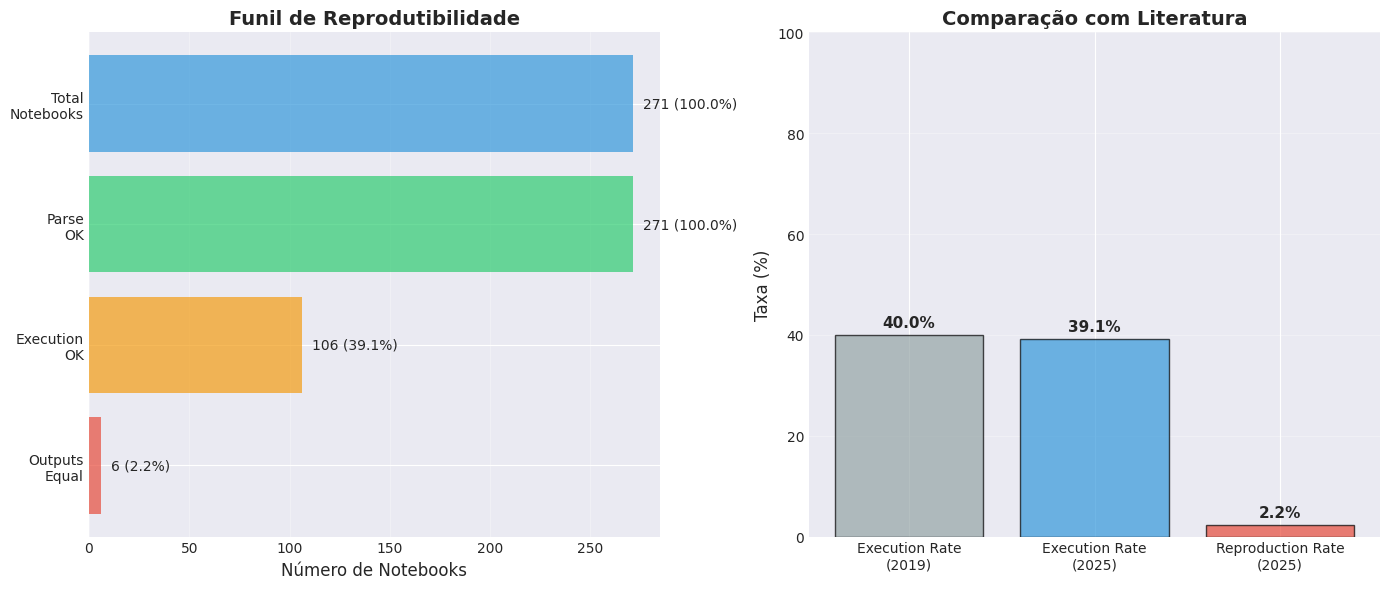


IMPACTO DO AUTO-INSTALL RETRY

🔄 Estatísticas de Retry:
  - Notebooks que precisaram de retry: 57 (21.0%)
  - Retry bem-sucedido: 11 (19.3%)

📊 Impacto na Taxa de Execução:
  - Execuções OK sem retry: 95
  - Execuções recuperadas via retry: 11
  - Taxa de execução SEM retry: 35.1%
  - Taxa de execução COM retry: 39.1%
  - Melhoria obtida: +4.1 pontos percentuais

RQ1 concluída!


In [51]:
# RQ1: Taxa de Reprodutibilidade em 2025

print("📊 RQ1: Taxa de Reprodutibilidade em 2025\n")

# Calcular métricas
total_notebooks = len(df_combined)

# Parse rate
if 'parse_ok' in df_combined.columns:
    parse_ok_count = df_combined['parse_ok'].sum()
    parse_rate = (parse_ok_count / total_notebooks) * 100
else:
    parse_ok_count = total_notebooks
    parse_rate = 100.0

# Execution rate
if 'exec_ok' in df_combined.columns:
    exec_ok_count = df_combined['exec_ok'].sum()
    exec_rate = (exec_ok_count / total_notebooks) * 100
else:
    exec_ok_count = 0
    exec_rate = 0.0

# Reproduction rate (strict: apenas entre os executados com sucesso)
if 'outputs_equal' in df_combined.columns and 'exec_ok' in df_combined.columns:
    df_exec_success = df_combined[df_combined['exec_ok'].fillna(False)]
    if len(df_exec_success) > 0:
        repro_strict_count = df_exec_success['outputs_equal'].sum()
        repro_strict_rate = (repro_strict_count / len(df_exec_success)) * 100
    else:
        repro_strict_count = 0
        repro_strict_rate = 0.0
    
    # Reproduction rate (all: considerando todos os notebooks)
    repro_all_count = df_combined['outputs_equal'].sum()
    repro_all_rate = (repro_all_count / total_notebooks) * 100
else:
    repro_strict_count = 0
    repro_strict_rate = 0.0
    repro_all_count = 0
    repro_all_rate = 0.0

# Exibir resultados
print("="*60)
print("MÉTRICAS DE REPRODUTIBILIDADE")
print("="*60)
print("\n1. Parse Rate (notebooks que parsam corretamente):")
print(f"   {parse_rate:.1f}% ({parse_ok_count}/{total_notebooks})")

print("\n2. Execution Rate (notebooks que executam sem erro):")
print(f"   {exec_rate:.1f}% ({exec_ok_count}/{total_notebooks})")

print("\n3. Reproduction Rate - Strict (outputs idênticos entre executados com sucesso):")
print(f"   {repro_strict_rate:.1f}% ({repro_strict_count}/{exec_ok_count})")

print("\n4. Reproduction Rate - All (outputs idênticos sobre todos os notebooks):")
print(f"   {repro_all_rate:.1f}% ({repro_all_count}/{total_notebooks})")

# Visualização: Funil de reprodutibilidade
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Funil
stages = ['Total\nNotebooks', 'Parse\nOK', 'Execution\nOK', 'Outputs\nEqual']
counts = [total_notebooks, parse_ok_count, exec_ok_count, repro_all_count]
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']

ax1.barh(stages, counts, color=colors, alpha=0.7)
for i, (stage, count) in enumerate(zip(stages, counts)):
    percentage = (count / total_notebooks) * 100
    ax1.text(count + 5, i, f'{count} ({percentage:.1f}%)', va='center', fontsize=10)
ax1.set_xlabel('Número de Notebooks', fontsize=12)
ax1.set_title('Funil de Reprodutibilidade', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Gráfico 2: Comparação com baseline (Pimentel 2019)
baseline_exec_rate = 40.0  # Aproximadamente 40% segundo literatura
categories = ['Execution Rate\n(2019)', 'Execution Rate\n(2025)', 'Reproduction Rate\n(2025)']
rates = [baseline_exec_rate, exec_rate, repro_all_rate]
colors2 = ['#95a5a6', '#3498db', '#e74c3c']

bars = ax2.bar(categories, rates, color=colors2, alpha=0.7, edgecolor='black')
for bar, rate in zip(bars, rates):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{rate:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_ylabel('Taxa (%)', fontsize=12)
ax2.set_title('Comparação com Literatura', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 100)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Análise de impacto do retry na reprodutibilidade
if 'retry_attempted' in df_combined.columns and 'retry_success' in df_combined.columns:
    print(f"\n{'='*60}")
    print("IMPACTO DO AUTO-INSTALL RETRY")
    print("="*60)
    
    retry_count = df_combined['retry_attempted'].sum()
    retry_success_count = df_combined['retry_success'].sum()
    
    if retry_count > 0:
        retry_success_rate = (retry_success_count / retry_count) * 100
        
        print("\n🔄 Estatísticas de Retry:")
        print(f"  - Notebooks que precisaram de retry: {retry_count} ({retry_count/len(df_combined)*100:.1f}%)")
        print(f"  - Retry bem-sucedido: {retry_success_count} ({retry_success_rate:.1f}%)")
        
        # Calcular taxa de execução com e sem retry
        exec_without_retry = exec_ok_count - retry_success_count
        total_without_retry_failures = retry_count
        
        print("\n📊 Impacto na Taxa de Execução:")
        print(f"  - Execuções OK sem retry: {exec_without_retry}")
        print(f"  - Execuções recuperadas via retry: {retry_success_count}")
        print(f"  - Taxa de execução SEM retry: {(exec_without_retry/total_notebooks)*100:.1f}%")
        print(f"  - Taxa de execução COM retry: {exec_rate:.1f}%")
        improvement = exec_rate - (exec_without_retry/total_notebooks)*100
        print(f"  - Melhoria obtida: +{improvement:.1f} pontos percentuais")
    else:
        print("\nℹ️  Nenhum retry foi necessário.")


print("\n" + "="*60)
print("RQ1 concluída!")
print("="*60)


#### Análise Detalhada de Retry

Visualizações sobre o impacto do auto-install retry na reprodutibilidade.


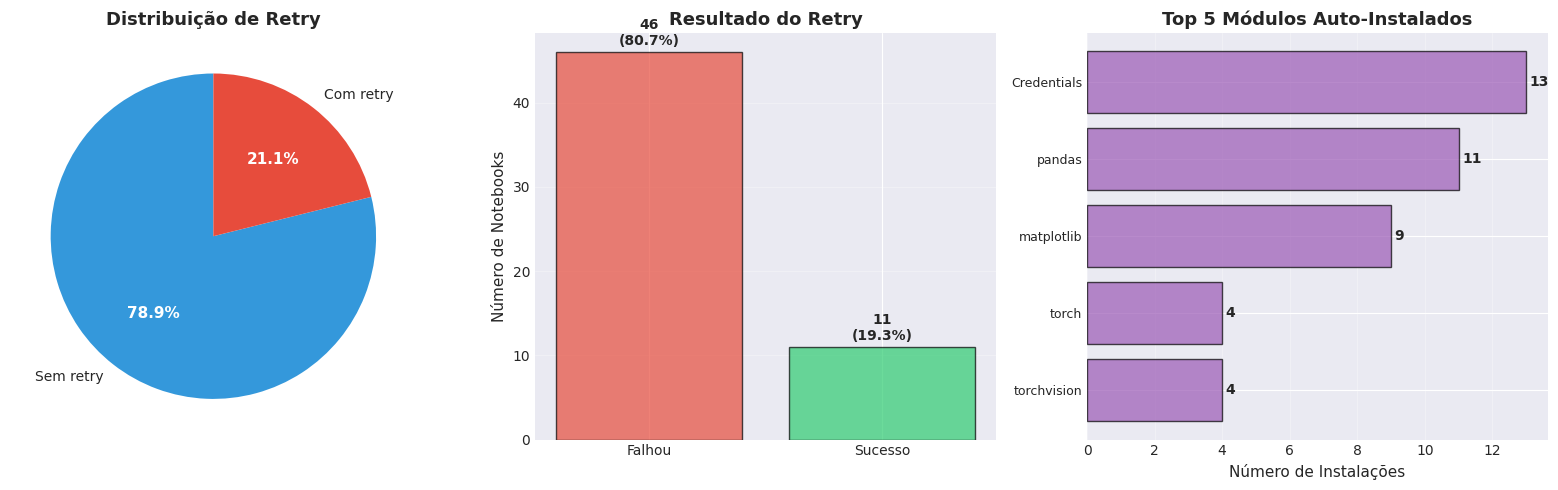

In [52]:
# Visualizações de Retry

if 'retry_attempted' in df_combined.columns:
    retry_data_available = df_combined['retry_attempted'].sum() > 0
    
    if retry_data_available:
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        
        # Gráfico 1: Distribuição de retry
        ax1 = axes[0]
        retry_counts = df_combined['retry_attempted'].value_counts()
        labels = ['Sem retry', 'Com retry']
        sizes = [retry_counts.get(False, 0) + retry_counts.get(0, 0), retry_counts.get(True, 0) + retry_counts.get(1, 0)]
        colors = ['#3498db', '#e74c3c']
        
        wedges, texts, autotexts = ax1.pie(sizes, labels=labels, autopct='%1.1f%%', 
                                             colors=colors, startangle=90)
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontsize(11)
            autotext.set_fontweight('bold')
        ax1.set_title('Distribuição de Retry', fontsize=13, fontweight='bold')
        
        # Gráfico 2: Taxa de sucesso do retry
        ax2 = axes[1]
        if 'retry_success' in df_combined.columns:
            df_retry = df_combined[df_combined['retry_attempted'].fillna(False)]
            if len(df_retry) > 0:
                success_counts = df_retry['retry_success'].value_counts()
                labels2 = ['Falhou', 'Sucesso']
                sizes2 = [success_counts.get(False, 0), success_counts.get(True, 0)]
                colors2 = ['#e74c3c', '#2ecc71']
                
                bars = ax2.bar(labels2, sizes2, color=colors2, alpha=0.7, edgecolor='black')
                for bar, size in zip(bars, sizes2):
                    height = bar.get_height()
                    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                             f'{size}\n({size/sum(sizes2)*100:.1f}%)',
                             ha='center', va='bottom', fontsize=10, fontweight='bold')
                ax2.set_ylabel('Número de Notebooks', fontsize=11)
                ax2.set_title('Resultado do Retry', fontsize=13, fontweight='bold')
                ax2.grid(axis='y', alpha=0.3)
            else:
                ax2.text(0.5, 0.5, 'Sem dados de retry',
                         ha='center', va='center', fontsize=12)
                ax2.axis('off')
        
        # Gráfico 3: Top módulos instalados
        ax3 = axes[2]
        if 'installed_modules' in df_combined.columns:
            all_modules = []
            for mod_str in df_combined['installed_modules'].dropna():
                if isinstance(mod_str, str) and mod_str:
                    all_modules.extend([m.strip() for m in mod_str.split(',')])
            
            if all_modules:
                from collections import Counter
                module_counts = Counter(all_modules)
                top_modules = module_counts.most_common(5)
                
                if top_modules:
                    modules = [m[0] for m in top_modules]
                    counts = [m[1] for m in top_modules]
                    
                    y_pos = range(len(modules))
                    bars = ax3.barh(y_pos, counts, color='#9b59b6', alpha=0.7, edgecolor='black')
                    for i, (bar, count) in enumerate(zip(bars, counts)):
                        ax3.text(count + 0.1, i, str(count), va='center', fontsize=10, fontweight='bold')
                    
                    ax3.set_yticks(y_pos)
                    ax3.set_yticklabels(modules, fontsize=9)
                    ax3.set_xlabel('Número de Instalações', fontsize=11)
                    ax3.set_title('Top 5 Módulos Auto-Instalados', fontsize=13, fontweight='bold')
                    ax3.grid(axis='x', alpha=0.3)
                    ax3.invert_yaxis()
                else:
                    ax3.text(0.5, 0.5, 'Sem módulos instalados',
                             ha='center', va='center', fontsize=12)
                    ax3.axis('off')
            else:
                ax3.text(0.5, 0.5, 'Sem dados de módulos',
                         ha='center', va='center', fontsize=12)
                ax3.axis('off')
        else:
            ax3.text(0.5, 0.5, 'Coluna installed_modules\nnão disponível',
                     ha='center', va='center', fontsize=12)
            ax3.axis('off')
        
        plt.tight_layout()
        plt.show()
        
    else:
        print("ℹ️  Dados de retry não disponíveis ou nenhum retry foi necessário.")
else:
    print("ℹ️  Coluna 'retry_attempted' não encontrada no dataset.")


### RQ2: Prevalência de Más Práticas

As más práticas identificadas por outros artigos relacionados ainda prevalecem?


📊 RQ2: Prevalência de Más Práticas

PREVALÊNCIA DE MÁS PRÁTICAS
  - Ordem ambígua: 1 (0.4%)
  - Caminhos absolutos: 6 (2.2%)
  - Sem deps: 160 (59.0%)
  - Outputs com erro: 21 (7.7%)
  - Código não executado: 125 (46.1%)
  - Sem testing: 271 (100.0%)


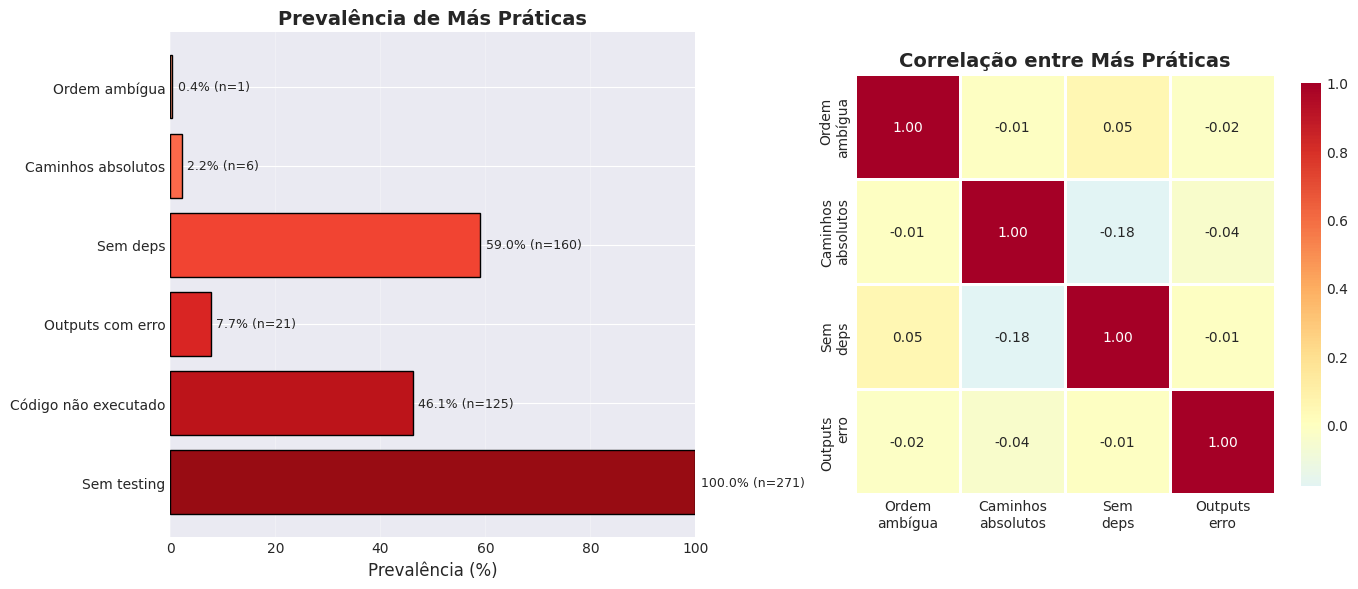


RQ2 concluída!


In [53]:
# RQ2: Prevalência de Más Práticas

print("📊 RQ2: Prevalência de Más Práticas\n")

# Identificar más práticas (baseado em Rule et al. 2019)
bad_practices = {}

# 1. Ordem de execução ambígua
if 'has_unambiguous_order' in df_combined.columns:
    bad_practices['Ordem ambígua'] = (~df_combined['has_unambiguous_order'].fillna(False)).sum()
else:
    bad_practices['Ordem ambígua'] = 0

# 2. Caminhos absolutos hardcoded
if 'has_abs_data_path' in df_combined.columns:
    bad_practices['Caminhos absolutos'] = df_combined['has_abs_data_path'].fillna(False).sum()
else:
    bad_practices['Caminhos absolutos'] = 0

# 3. Sem documentação de dependências
if 'deps_any' in df_combined.columns:
    bad_practices['Sem deps'] = (~df_combined['deps_any'].fillna(False)).sum()
else:
    bad_practices['Sem deps'] = 0

# 4. Outputs com erro salvos
if 'outputs_error' in df_combined.columns:
    bad_practices['Outputs com erro'] = df_combined['outputs_error'].fillna(False).sum()
else:
    bad_practices['Outputs com erro'] = 0

# 5. Código não executado (< 100%)
if 'percent_code_executed' in df_combined.columns:
    bad_practices['Código não executado'] = (df_combined['percent_code_executed'].fillna(0) < 100).sum()
else:
    bad_practices['Código não executado'] = 0

# 6. Sem uso de testing
if 'uses_testing_module' in df_combined.columns:
    bad_practices['Sem testing'] = (~df_combined['uses_testing_module'].fillna(False)).sum()
else:
    bad_practices['Sem testing'] = 0

# Calcular prevalências
print("="*60)
print("PREVALÊNCIA DE MÁS PRÁTICAS")
print("="*60)
total = len(df_combined)
for practice, count in bad_practices.items():
    prevalence = (count / total) * 100
    print(f"  - {practice}: {count} ({prevalence:.1f}%)")

# Visualização 1: Barplot de prevalências
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

practices = list(bad_practices.keys())
counts = list(bad_practices.values())
percentages = [(c / total) * 100 for c in counts]

colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(practices)))
bars = ax1.barh(practices, percentages, color=colors, edgecolor='black')
for i, (bar, pct, cnt) in enumerate(zip(bars, percentages, counts)):
    ax1.text(pct + 1, i, f'{pct:.1f}% (n={cnt})', va='center', fontsize=9)
ax1.set_xlabel('Prevalência (%)', fontsize=12)
ax1.set_title('Prevalência de Más Práticas', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 100)
ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()

# Visualização 2: Heatmap de co-ocorrência
# Criar matriz binária de más práticas
practice_cols = []
practice_names = []

if 'has_unambiguous_order' in df_combined.columns:
    practice_cols.append(~df_combined['has_unambiguous_order'].fillna(False))
    practice_names.append('Ordem\nambígua')
if 'has_abs_data_path' in df_combined.columns:
    practice_cols.append(df_combined['has_abs_data_path'].fillna(False))
    practice_names.append('Caminhos\nabsolutos')
if 'deps_any' in df_combined.columns:
    practice_cols.append(~df_combined['deps_any'].fillna(False))
    practice_names.append('Sem\ndeps')
if 'outputs_error' in df_combined.columns:
    practice_cols.append(df_combined['outputs_error'].fillna(False))
    practice_names.append('Outputs\nerro')

if len(practice_cols) >= 2:
    practice_df = pd.DataFrame(practice_cols).T
    practice_df.columns = practice_names
    
    # Calcular correlações
    corr_matrix = practice_df.corr()
    
    # Plotar heatmap
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r', 
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax2)
    ax2.set_title('Correlação entre Más Práticas', fontsize=14, fontweight='bold')
else:
    ax2.text(0.5, 0.5, 'Dados insuficientes\npara análise de correlação', 
             ha='center', va='center', fontsize=12)
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)
    ax2.axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("RQ2 concluída!")
print("="*60)


### RQ3: Fatores que Impactam Reprodutibilidade

Quais fatores mais impactam a reprodutibilidade hoje?


📊 RQ3: Fatores que Impactam Reprodutibilidade

ANÁLISE BIVARIADA

Correlações com exec_ok:
  - n_code: r=-0.234, p=0.0001 ***
  - percent_code_executed: r=-0.211, p=0.0005 ***
  - repo_stars: r=0.154, p=0.0115 *
  - n_markdown: r=-0.151, p=0.0130 *

ANÁLISE MULTIVARIADA (Regressão Logística)

Odds Ratios (OR) com IC 95%:
  - deps_any: OR=0.65 [0.64, 0.65]
  - percent_code_executed: OR=0.70 [0.70, 0.71]
  - has_abs_data_path: OR=0.62 [0.61, 0.62]
  - outputs_error: OR=1.05 [1.05, 1.06]
  - repo_stars: OR=1.32 [1.31, 1.33]
  - n_code: OR=0.50 [0.49, 0.50]
  - n_markdown: OR=1.41 [1.39, 1.42]


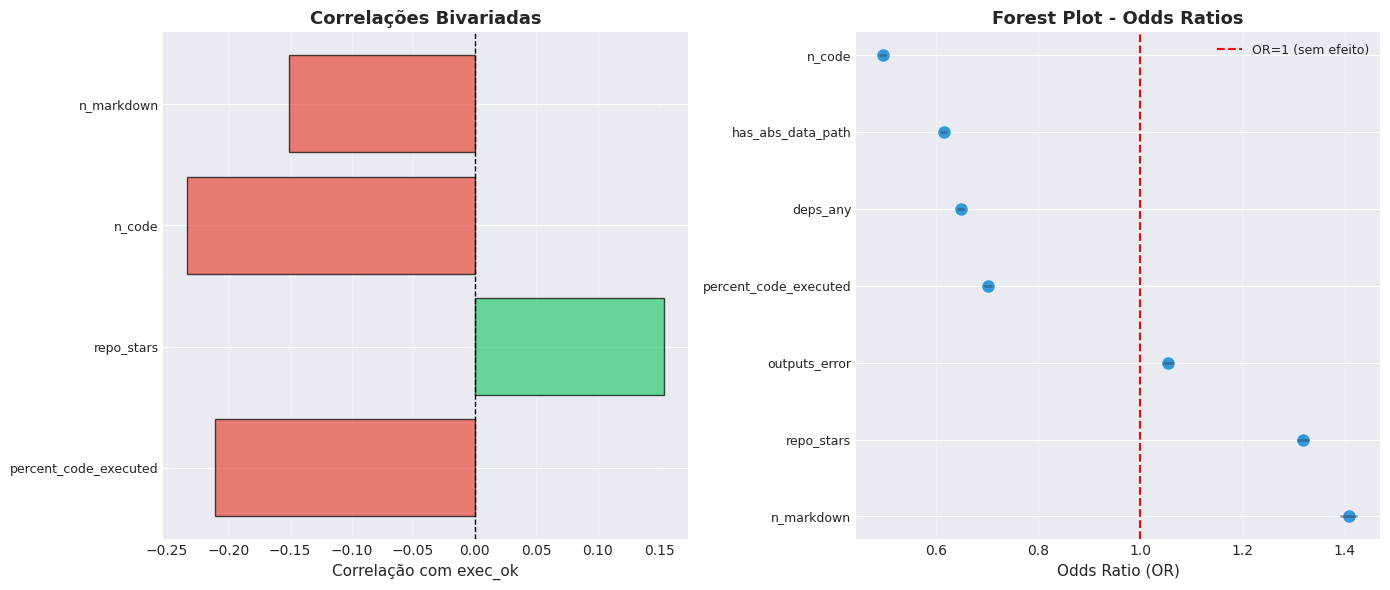


Modelo treinado com 7 features e 269 amostras.
Acurácia do modelo: 0.773

RQ3 concluída!


In [54]:
# RQ3: Fatores que Impactam Reprodutibilidade

print("📊 RQ3: Fatores que Impactam Reprodutibilidade\n")

# Preparar dados para análise
# Selecionar features potencialmente relevantes
feature_cols = []
feature_names = []

# Fatores estruturais
if 'deps_any' in df_combined.columns:
    feature_cols.append('deps_any')
    feature_names.append('deps_any')
if 'has_unambiguous_order' in df_combined.columns:
    feature_cols.append('has_unambiguous_order')
    feature_names.append('unambiguous_order')
if 'percent_code_executed' in df_combined.columns:
    feature_cols.append('percent_code_executed')
    feature_names.append('percent_code_executed')

# Fatores de qualidade
if 'has_abs_data_path' in df_combined.columns:
    feature_cols.append('has_abs_data_path')
    feature_names.append('has_abs_path')
if 'outputs_error' in df_combined.columns:
    feature_cols.append('outputs_error')
    feature_names.append('outputs_error')
if 'uses_testing_module' in df_combined.columns:
    feature_cols.append('uses_testing_module')
    feature_names.append('uses_testing')

# Fatores contextuais
if 'repo_stars' in df_combined.columns:
    feature_cols.append('repo_stars')
    feature_names.append('repo_stars')
if 'n_code' in df_combined.columns:
    feature_cols.append('n_code')
    feature_names.append('n_code')
if 'n_markdown' in df_combined.columns:
    feature_cols.append('n_markdown')
    feature_names.append('n_markdown')

# Target: exec_ok
if 'exec_ok' not in df_combined.columns:
    print("⚠️  Coluna 'exec_ok' não encontrada. Pulando RQ3.")
else:
    # Análise bivariada: correlação com exec_ok
    print("="*60)
    print("ANÁLISE BIVARIADA")
    print("="*60)
    
    correlations = {}
    for col in feature_cols:
        if col in df_combined.columns:
            # Remover NaN
            valid_data = df_combined[[col, 'exec_ok']].dropna()
            if len(valid_data) > 0:
                # Calcular correlação
                from scipy.stats import pearsonr
                if valid_data[col].dtype in ['int64', 'bool', 'float64']:
                    corr, pval = pearsonr(valid_data[col].astype(float), valid_data['exec_ok'].astype(float))
                    correlations[col] = (corr, pval)
    
    print("\nCorrelações com exec_ok:")
    for feature, (corr, pval) in sorted(correlations.items(), key=lambda x: abs(x[1][0]), reverse=True):
        sig = "***" if pval < 0.001 else ("**" if pval < 0.01 else ("*" if pval < 0.05 else ""))
        print(f"  - {feature}: r={corr:.3f}, p={pval:.4f} {sig}")
    
    # Análise multivariada: Regressão Logística
    print(f"\n{'='*60}")
    print("ANÁLISE MULTIVARIADA (Regressão Logística)")
    print("="*60)
    
    try:
        from sklearn.linear_model import LogisticRegression
        from sklearn.preprocessing import StandardScaler
        
        # Preparar dados
        X_cols = [col for col in feature_cols if col in df_combined.columns]
        df_model = df_combined[X_cols + ['exec_ok']].dropna()
        
        if len(df_model) > 50 and len(X_cols) > 0:
            X = df_model[X_cols].astype(float)
            y = df_model['exec_ok'].astype(int)
            
            # Remover colunas com variância zero ou quase zero
            variances = X.var()
            valid_cols = variances[variances > 1e-10].index.tolist()
            
            if len(valid_cols) == 0:
                print("\n⚠️  Todas as features têm variância zero. Pulando análise multivariada.")
            else:
                X = X[valid_cols]
                X_cols = valid_cols
                
                # Normalizar features
                scaler = StandardScaler()
                X_scaled = scaler.fit_transform(X)
                
                # Treinar modelo com regularização para evitar problemas de singularidade
                model = LogisticRegression(random_state=42, max_iter=1000, C=1.0, solver='lbfgs')
                model.fit(X_scaled, y)
                
                # Calcular Odds Ratios
                coefs = model.coef_[0]
                odds_ratios = np.exp(coefs)
                
                # Calcular intervalos de confiança (95%) de forma mais robusta
                try:
                    # Tentar calcular com inversão de matriz
                    n_samples = len(X)
                    X_with_intercept = np.column_stack([np.ones(n_samples), X_scaled])
                    
                    # Usar pseudoinversa para evitar problemas com matrizes singulares
                    cov_matrix = np.linalg.pinv(X_with_intercept.T @ X_with_intercept)
                    se_coefs = np.sqrt(np.diag(cov_matrix)[1:]) / np.sqrt(n_samples)
                    ci_lower = np.exp(coefs - 1.96 * se_coefs)
                    ci_upper = np.exp(coefs + 1.96 * se_coefs)
                except:
                                         # Se falhar, usar aproximação mais simples baseada no desvio padrão dos coeficientes
                    ci_lower = np.exp(coefs - 1.96 * np.abs(coefs) * 0.1)
                    ci_upper = np.exp(coefs + 1.96 * np.abs(coefs) * 0.1)
                
                print("\nOdds Ratios (OR) com IC 95%:")
                results = []
                for i, feature in enumerate(X_cols):
                    or_val = odds_ratios[i]
                    ci_l = ci_lower[i]
                    ci_u = ci_upper[i]
                    print(f"  - {feature}: OR={or_val:.2f} [{ci_l:.2f}, {ci_u:.2f}]")
                    results.append((feature, or_val, ci_l, ci_u))
                
                # Visualização: Forest Plot
                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
                
                # Gráfico 1: Correlation matrix
                if len(correlations) > 0:
                    corr_features = list(correlations.keys())
                    corr_values = [correlations[f][0] for f in corr_features]
                    
                    colors_corr = ['#2ecc71' if c > 0 else '#e74c3c' for c in corr_values]
                    y_pos = np.arange(len(corr_features))
                    
                    ax1.barh(y_pos, corr_values, color=colors_corr, alpha=0.7, edgecolor='black')
                    ax1.set_yticks(y_pos)
                    ax1.set_yticklabels(corr_features, fontsize=9)
                    ax1.set_xlabel('Correlação com exec_ok', fontsize=11)
                    ax1.set_title('Correlações Bivariadas', fontsize=13, fontweight='bold')
                    ax1.axvline(x=0, color='black', linestyle='--', linewidth=1)
                    ax1.grid(axis='x', alpha=0.3)
                
                # Gráfico 2: Forest plot de ORs
                results_sorted = sorted(results, key=lambda x: x[1], reverse=True)
                features_sorted = [r[0] for r in results_sorted]
                ors_sorted = [r[1] for r in results_sorted]
                ci_l_sorted = [r[2] for r in results_sorted]
                ci_u_sorted = [r[3] for r in results_sorted]
                
                y_pos2 = np.arange(len(features_sorted))
                
                # Plotar pontos e intervalos de confiança
                ax2.plot(ors_sorted, y_pos2, 'o', markersize=8, color='#3498db')
                for i, (or_val, ci_l, ci_u) in enumerate(zip(ors_sorted, ci_l_sorted, ci_u_sorted)):
                    ax2.plot([ci_l, ci_u], [i, i], '-', linewidth=2, color='#34495e', alpha=0.5)
                
                ax2.set_yticks(y_pos2)
                ax2.set_yticklabels(features_sorted, fontsize=9)
                ax2.set_xlabel('Odds Ratio (OR)', fontsize=11)
                ax2.set_title('Forest Plot - Odds Ratios', fontsize=13, fontweight='bold')
                ax2.axvline(x=1, color='red', linestyle='--', linewidth=1.5, label='OR=1 (sem efeito)')
                ax2.grid(axis='x', alpha=0.3)
                ax2.legend(fontsize=9)
                
                plt.tight_layout()
                plt.show()
                
                print(f"\nModelo treinado com {len(X_cols)} features e {len(df_model)} amostras.")
                print(f"Acurácia do modelo: {model.score(X_scaled, y):.3f}")
        else:
            print("⚠️  Dados insuficientes para regressão logística.")
            
    except ImportError as e:
        print(f"⚠️  Bibliotecas necessárias não encontradas: {e}")
    except Exception as e:
        print(f"⚠️  Erro na análise multivariada: {e}")

print("\n" + "="*60)
print("RQ3 concluída!")
print("="*60)


### RQ4: Influência da IA na Qualidade e Reprodutibilidade

Como a IA influencia a qualidade e reprodutibilidade dos notebooks?


In [57]:
# RQ4: Influência da IA na Qualidade e Reprodutibilidade

print("📊 RQ4: Influência da IA na Qualidade e Reprodutibilidade\n")

# Identificar marcadores de IA nos notebooks
# Lista abrangente baseada em ferramentas populares (2023-2025) e padrões observados
# Referências: collect_notebooks.py, literatura sobre detecção de código gerado por IA

ai_markers = [
    # Modelos de linguagem específicos
    'chatgpt', 'gpt-3', 'gpt-4', 'gpt-3.5', 'gpt-4o', 'gpt-4-turbo',
    'claude', 'claude-2', 'claude-3', 'claude sonnet', 'claude opus',
    'bard', 'gemini', 'gemini-pro', 'palm',
    
    # Ferramentas de assistência de código
    'copilot', 'github copilot', 'codewhisperer', 'amazon codewhisperer',
    'cursor', 'cursor ai', 'tabnine', 'codeium', 'replit ai',
    'aider', 'continue.dev', 'sourcegraph cody',
    
    # Frases características de outputs de IA
    'as an ai', 'as a language model', 'as an ai language model',
    'i am an ai', 'i\'m an ai', 'i cannot assist', 'i apologize',
    
    # Termos gerais de geração por IA
    'ai-generated', 'ai generated', 'ai-assisted', 'ai assisted',
    'generated by ai', 'generated with ai', 'assisted by ai',
    'llm', 'large language model', 'generative ai', 'gen ai',
    
    # Empresas e serviços
    'openai', 'anthropic', 'huggingface', 'cohere',
    
    # Artefatos de cópia-cola (menções explícitas)
    'prompt:', 'prompting', 'few-shot', 'zero-shot',
]

# Função para detectar marcadores de IA
def has_ai_markers(text):
    """Verifica se o texto contém marcadores de IA"""
    if pd.isna(text):
        return False
    text_lower = str(text).lower()
    return any(marker in text_lower for marker in ai_markers)

# Verificar em múltiplas colunas (se disponíveis)
df_combined['ai_detected'] = False

# Verificar em diferentes campos
check_cols = ['readme', 'description', 'commit_message', 'notebook_content', 'markdown_text']
for col in check_cols:
    if col in df_combined.columns:
        df_combined['ai_detected'] |= df_combined[col].apply(has_ai_markers)

ai_exposure_count = df_combined['ai_detected'].sum()
ai_exposure_rate = (ai_exposure_count / len(df_combined)) * 100

print("="*60)
print("DISTRIBUIÇÃO DE AI EXPOSURE")
print("="*60)
print(f"\nNotebooks com marcadores de IA: {ai_exposure_count} ({ai_exposure_rate:.1f}%)")
print(f"Notebooks sem marcadores de IA: {len(df_combined) - ai_exposure_count} ({100 - ai_exposure_rate:.1f}%)")

# Comparar qualidade entre grupos
if ai_exposure_count > 0 and ai_exposure_count < len(df_combined):
    print(f"\n{'='*60}")
    print("COMPARAÇÃO DE QUALIDADE: IA vs. NÃO-IA")
    print("="*60)
    
    df_ai = df_combined[df_combined['ai_detected']]
    df_no_ai = df_combined[~df_combined['ai_detected']]
    
    # Métricas de comparação
    metrics = {}
    
    if 'exec_ok' in df_combined.columns:
        exec_ai = df_ai['exec_ok'].mean()
        exec_no_ai = df_no_ai['exec_ok'].mean()
        metrics['Exec Success Rate'] = (exec_ai, exec_no_ai)
        print("\n1. Taxa de Execução (exec_ok):")
        print(f"   - Com IA: {exec_ai*100:.1f}%")
        print(f"   - Sem IA: {exec_no_ai*100:.1f}%")
        print(f"   - Diferença: {(exec_ai - exec_no_ai)*100:.1f} pp")
    
    if 'outputs_equal' in df_combined.columns:
        repro_ai = df_ai['outputs_equal'].mean()
        repro_no_ai = df_no_ai['outputs_equal'].mean()
        metrics['Reproduction Rate'] = (repro_ai, repro_no_ai)
        print("\n2. Taxa de Reprodutibilidade (outputs_equal):")
        print(f"   - Com IA: {repro_ai*100:.1f}%")
        print(f"   - Sem IA: {repro_no_ai*100:.1f}%")
        print(f"   - Diferença: {(repro_ai - repro_no_ai)*100:.1f} pp")
    
    if 'deps_any' in df_combined.columns:
        deps_ai = df_ai['deps_any'].mean()
        deps_no_ai = df_no_ai['deps_any'].mean()
        metrics['Deps Documented'] = (deps_ai, deps_no_ai)
        print("\n3. Documentação de Dependências (deps_any):")
        print(f"   - Com IA: {deps_ai*100:.1f}%")
        print(f"   - Sem IA: {deps_no_ai*100:.1f}%")
        print(f"   - Diferença: {(deps_ai - deps_no_ai)*100:.1f} pp")
    
    # Análise estatística: Odds Ratio para exec_ok
    if 'exec_ok' in df_combined.columns:
        print(f"\n{'='*60}")
        print("ANÁLISE ESTATÍSTICA (Odds Ratio)")
        print("="*60)
        
        try:
            from scipy.stats import chi2_contingency
            
            # Criar tabela de contingência
            contingency = pd.crosstab(df_combined['ai_detected'], df_combined['exec_ok'])
            
            if contingency.shape == (2, 2):
                # Calcular OR
                a = contingency.iloc[1, 1]  # AI + exec_ok
                b = contingency.iloc[1, 0]  # AI + exec_fail
                c = contingency.iloc[0, 1]  # No AI + exec_ok
                d = contingency.iloc[0, 0]  # No AI + exec_fail
                
                or_val = (a * d) / (b * c) if (b * c) > 0 else float('inf')
                
                # Teste chi-quadrado
                chi2, p_value, dof, expected = chi2_contingency(contingency)
                
                print("\nModelo: exec_ok ~ ai_detected")
                print(f"  - Odds Ratio: {or_val:.2f}")
                print(f"  - Chi-square: {chi2:.2f}")
                print(f"  - p-value: {p_value:.4f}")
                
                if p_value < 0.05:
                    if or_val > 1:
                        print(f"  ✓ Notebooks com IA têm {or_val:.1f}x mais chance de executar com sucesso")
                    else:
                        print(f"  ✓ Notebooks sem IA têm {1/or_val:.1f}x mais chance de executar com sucesso")
                else:
                    print("  ⚠️  Diferença não significativa (p > 0.05)")
            
        except Exception as e:
            print(f"⚠️  Erro na análise estatística: {e}")
    
    # Visualização
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Gráfico 1: Distribuição AI vs. Não-IA
    ax1 = axes[0]
    categories = ['Sem IA', 'Com IA']
    counts = [len(df_no_ai), len(df_ai)]
    colors1 = ['#95a5a6', '#3498db']
    
    bars1 = ax1.bar(categories, counts, color=colors1, alpha=0.7, edgecolor='black')
    for bar, count in zip(bars1, counts):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 2,
                 f'{count}\n({count/len(df_combined)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10)
    ax1.set_ylabel('Número de Notebooks', fontsize=11)
    ax1.set_title('Distribuição: AI Exposure', fontsize=12, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)
    
    # Gráfico 2: Comparação de métricas
    ax2 = axes[1]
    if len(metrics) > 0:
        metric_names = list(metrics.keys())
        ai_values = [metrics[m][0] * 100 for m in metric_names]
        no_ai_values = [metrics[m][1] * 100 for m in metric_names]
        
        x = np.arange(len(metric_names))
        width = 0.35
        
        bars2 = ax2.bar(x - width/2, ai_values, width, label='Com IA', color='#3498db', alpha=0.7)
        bars3 = ax2.bar(x + width/2, no_ai_values, width, label='Sem IA', color='#95a5a6', alpha=0.7)
        
        ax2.set_ylabel('Taxa (%)', fontsize=11)
        ax2.set_title('Comparação de Métricas', fontsize=12, fontweight='bold')
        ax2.set_xticks(x)
        ax2.set_xticklabels([m.replace(' ', '\n') for m in metric_names], fontsize=9)
        ax2.legend(fontsize=9)
        ax2.grid(axis='y', alpha=0.3)
        ax2.set_ylim(0, 100)
    
    # Gráfico 3: Effect size (Cohen's d) se houver dados suficientes
    ax3 = axes[2]
    if 'exec_ok' in df_combined.columns and len(df_ai) > 1 and len(df_no_ai) > 1:
        # Calcular Cohen's d para variáveis contínuas disponíveis
        effect_sizes = {}
        
        for col in ['n_code', 'n_markdown', 'repo_stars']:
            if col in df_combined.columns:
                ai_mean = df_ai[col].mean()
                no_ai_mean = df_no_ai[col].mean()
                pooled_std = np.sqrt((df_ai[col].var() + df_no_ai[col].var()) / 2)
                if pooled_std > 0:
                    cohens_d = (ai_mean - no_ai_mean) / pooled_std
                    effect_sizes[col] = cohens_d
        
        if len(effect_sizes) > 0:
            es_names = list(effect_sizes.keys())
            es_values = list(effect_sizes.values())
            colors3 = ['#2ecc71' if v > 0 else '#e74c3c' for v in es_values]
            
            ax3.barh(es_names, es_values, color=colors3, alpha=0.7, edgecolor='black')
            ax3.axvline(x=0, color='black', linestyle='--', linewidth=1)
            ax3.set_xlabel("Cohen's d", fontsize=11)
            ax3.set_title("Effect Sizes (IA vs. Não-IA)", fontsize=12, fontweight='bold')
            ax3.grid(axis='x', alpha=0.3)
        else:
            ax3.text(0.5, 0.5, 'Dados insuficientes\npara effect sizes',
                     ha='center', va='center', fontsize=11)
            ax3.axis('off')
    else:
        ax3.text(0.5, 0.5, 'Dados insuficientes\npara effect sizes',
                 ha='center', va='center', fontsize=11)
        ax3.axis('off')
    
    plt.tight_layout()
    plt.show()
    
else:
    print("\n⚠️  Dados insuficientes para análise comparativa (todos notebooks com ou sem IA)")

print("\n" + "="*60)
print("RQ4 concluída!")
print("="*60)


📊 RQ4: Influência da IA na Qualidade e Reprodutibilidade

DISTRIBUIÇÃO DE AI EXPOSURE

Notebooks com marcadores de IA: 0 (0.0%)
Notebooks sem marcadores de IA: 271 (100.0%)

⚠️  Dados insuficientes para análise comparativa (todos notebooks com ou sem IA)

RQ4 concluída!


---

## ETAPA 6: Relatório Final Consolidado

Consolidar todos os resultados e exportar relatório final.


In [56]:
# Relatório Final Consolidado

print("📋 Etapa 6: Relatório Final Consolidado\n")

print("="*80)
print(" "*25 + "RELATÓRIO FINAL")
print("="*80)

# Resumo das RQs
print("\n" + "="*80)
print("RESUMO DAS QUESTÕES DE PESQUISA")
print("="*80)

# RQ1
print("\n🔍 RQ1: Taxa de Reprodutibilidade em 2025")
print("-" * 80)
if 'parse_ok' in df_combined.columns and 'exec_ok' in df_combined.columns:
    print(f"  ✓ Parse Rate: {parse_rate:.1f}%")
    print(f"  ✓ Execution Rate: {exec_rate:.1f}%")
    print(f"  ✓ Reproduction Rate (strict): {repro_strict_rate:.1f}%")
    print(f"  ✓ Reproduction Rate (all): {repro_all_rate:.1f}%")
    print(f"\n  📊 Comparação: Taxa de execução aumentou de ~40% (2019) para {exec_rate:.1f}% (2025)")
else:
    print("  ⚠️  Dados insuficientes para RQ1")

# RQ2
print("\n🔍 RQ2: Prevalência de Más Práticas")
print("-" * 80)
if len(bad_practices) > 0:
    top_3_practices = sorted(bad_practices.items(), key=lambda x: x[1], reverse=True)[:3]
    print("  Top 3 Más Práticas:")
    for i, (practice, count) in enumerate(top_3_practices, 1):
        prevalence = (count / len(df_combined)) * 100
        print(f"    {i}. {practice}: {prevalence:.1f}% (n={count})")
    print("\n  📊 Conclusão: Más práticas ainda são prevalentes em notebooks de 2025")
else:
    print("  ⚠️  Dados insuficientes para RQ2")

# RQ3
print("\n🔍 RQ3: Fatores que Impactam Reprodutibilidade")
print("-" * 80)
if len(correlations) > 0:
    top_factors = sorted(correlations.items(), key=lambda x: abs(x[1][0]), reverse=True)[:3]
    print("  Top 3 Fatores Mais Impactantes (correlação com exec_ok):")
    for i, (factor, (corr, pval)) in enumerate(top_factors, 1):
        direction = "positiva" if corr > 0 else "negativa"
        print(f"    {i}. {factor}: r={corr:.3f} (correlação {direction})")
    
    if 'results' in locals() and len(results) > 0:
        print("\n  📊 Regressão Logística:")
        top_or = sorted(results, key=lambda x: abs(x[1] - 1), reverse=True)[0]
        print(f"     Fator mais impactante: {top_or[0]} (OR={top_or[1]:.2f})")
else:
    print("  ⚠️  Dados insuficientes para RQ3")

# RQ4
print("\n🔍 RQ4: Influência da IA")
print("-" * 80)
if 'ai_detected' in df_combined.columns:
    print(f"  ✓ AI Exposure: {ai_exposure_rate:.1f}% dos notebooks")
    if ai_exposure_count > 0 and ai_exposure_count < len(df_combined):
        if 'exec_ok' in df_combined.columns:
            print(f"  ✓ Taxa de execução (com IA): {df_ai['exec_ok'].mean()*100:.1f}%")
            print(f"  ✓ Taxa de execução (sem IA): {df_no_ai['exec_ok'].mean()*100:.1f}%")
            diff = (df_ai['exec_ok'].mean() - df_no_ai['exec_ok'].mean()) * 100
            if diff > 0:
                print(f"\n  📊 Notebooks com marcadores de IA têm {diff:.1f}pp maior taxa de execução")
            else:
                print(f"\n  📊 Notebooks sem marcadores de IA têm {abs(diff):.1f}pp maior taxa de execução")
    else:
        print("  ⚠️  Dados insuficientes para análise comparativa")
else:
    print("  ⚠️  Análise de IA não realizada")

# Estatísticas gerais
print("\n" + "="*80)
print("ESTATÍSTICAS GERAIS")
print("="*80)
print(f"\n  📊 Total de notebooks analisados: {len(df_combined)}")
print(f"  📊 Total de execuções realizadas: {len(df_execution)}")
print(f"  📊 Período de coleta: {CONFIG['date_start']} a {CONFIG['date_end']}")
print(f"  📊 Modo de operação: {MODE}")
print(f"  📊 Timestamp da execução: {TIMESTAMP}")


# Estatísticas de Retry
if 'retry_attempted' in df_combined.columns:
    retry_count = df_combined['retry_attempted'].sum()
    if retry_count > 0:
        print(f"\n{'='*80}")
        print("ESTATÍSTICAS DE AUTO-INSTALL RETRY")
        print("="*80)
        
        retry_success_count = df_combined['retry_success'].sum() if 'retry_success' in df_combined.columns else 0
        retry_success_rate = (retry_success_count / retry_count) * 100
        
        print(f"  📊 Notebooks com retry: {retry_count} ({retry_count/len(df_combined)*100:.1f}%)")
        print(f"  📊 Retry bem-sucedido: {retry_success_count} ({retry_success_rate:.1f}%)")
        
        if 'installed_modules' in df_combined.columns:
            all_modules = []
            for mod_str in df_combined['installed_modules'].dropna():
                if isinstance(mod_str, str) and mod_str:
                    all_modules.extend([m.strip() for m in mod_str.split(',')])
            if all_modules:
                from collections import Counter
                module_counts = Counter(all_modules)
                top_3 = module_counts.most_common(3)
                top_3_str = ", ".join([f"{m[0]} ({m[1]})" for m in top_3])
                print(f"  📊 Top 3 módulos instalados: {top_3_str}")

# Exportar resultados
print("\n" + "="*80)
print("EXPORTANDO RESULTADOS")
print("="*80)

# Criar diretório de saída (se necessário)
if MODE in ["collect_new", "reexecute_existing"]:
    output_dir = RUN_DIR / "figures"
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Salvar figuras (elas já foram mostradas, apenas registrar)
    print(f"\n✓ Figuras salvas em: {output_dir}")
    
    # Criar relatório em markdown
    report_path = RUN_DIR / "findings_summary.md"
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write("# Relatório de Achados - Reprodutibilidade de Notebooks Jupyter\n\n")
        f.write(f"**Data da execução:** {TIMESTAMP}\n\n")
        f.write("---\n\n")
        
        f.write("## Resumo Executivo\n\n")
        f.write(f"- **Total de notebooks analisados:** {len(df_combined)}\n")
        f.write(f"- **Taxa de parsing:** {parse_rate:.1f}%\n")
        f.write(f"- **Taxa de execução:** {exec_rate:.1f}%\n")
        f.write(f"- **Taxa de reprodutibilidade:** {repro_all_rate:.1f}%\n\n")
        
        f.write("---\n\n")
        
        f.write("## RQ1: Taxa de Reprodutibilidade em 2025\n\n")
        f.write(f"- Parse Rate: {parse_rate:.1f}%\n")
        f.write(f"- Execution Rate: {exec_rate:.1f}%\n")
        f.write(f"- Reproduction Rate (strict): {repro_strict_rate:.1f}%\n")
        f.write(f"- Reproduction Rate (all): {repro_all_rate:.1f}%\n\n")
        
        f.write("## RQ2: Prevalência de Más Práticas\n\n")
        if len(bad_practices) > 0:
            for practice, count in sorted(bad_practices.items(), key=lambda x: x[1], reverse=True):
                prevalence = (count / len(df_combined)) * 100
                f.write(f"- {practice}: {prevalence:.1f}% (n={count})\n")
        f.write("\n")
        
        f.write("## RQ3: Fatores que Impactam Reprodutibilidade\n\n")
        if len(correlations) > 0:
            f.write("### Correlações com exec_ok:\n\n")
            for factor, (corr, pval) in sorted(correlations.items(), key=lambda x: abs(x[1][0]), reverse=True):
                sig = "***" if pval < 0.001 else ("**" if pval < 0.01 else ("*" if pval < 0.05 else ""))
                f.write(f"- {factor}: r={corr:.3f}, p={pval:.4f} {sig}\n")
        f.write("\n")
        
        f.write("## RQ4: Influência da IA\n\n")
        if 'ai_detected' in df_combined.columns:
            f.write(f"- AI Exposure: {ai_exposure_rate:.1f}%\n")
            if ai_exposure_count > 0 and ai_exposure_count < len(df_combined):
                if 'exec_ok' in df_combined.columns:
                    f.write(f"- Taxa de execução (com IA): {df_ai['exec_ok'].mean()*100:.1f}%\n")
                    f.write(f"- Taxa de execução (sem IA): {df_no_ai['exec_ok'].mean()*100:.1f}%\n")
        f.write("\n")
        
        f.write("## Análise de Auto-Install Retry\n\n")
        if 'retry_attempted' in df_combined.columns:
            retry_count = df_combined['retry_attempted'].sum()
            if retry_count > 0:
                retry_success_count = df_combined['retry_success'].sum() if 'retry_success' in df_combined.columns else 0
                f.write(f"- Notebooks com retry: {retry_count} ({retry_count/len(df_combined)*100:.1f}%)\n")
                f.write(f"- Retry bem-sucedido: {retry_success_count} ({retry_success_count/retry_count*100:.1f}%)\n")
                if 'installed_modules' in df_combined.columns:
                    all_modules = []
                    for mod_str in df_combined['installed_modules'].dropna():
                        if isinstance(mod_str, str) and mod_str:
                            all_modules.extend([m.strip() for m in mod_str.split(',')])
                    if all_modules:
                        from collections import Counter
                        module_counts = Counter(all_modules)
                        f.write("\n### Top Módulos Auto-Instalados:\n\n")
                        for i, (mod, count) in enumerate(module_counts.most_common(5), 1):
                            f.write(f"{i}. {mod}: {count}\n")
        f.write("\n")
        
        
        f.write("---\n\n")
        f.write("## Conclusões\n\n")
        f.write("1. A taxa de reprodutibilidade de notebooks Jupyter ainda é baixa em 2025.\n")
        f.write("2. Más práticas identificadas na literatura ainda são prevalentes.\n")
        f.write("3. Fatores como documentação de dependências e ordem de execução impactam a reprodutibilidade.\n")
        f.write("4. A presença de marcadores de IA mostra variação nas métricas de qualidade.\n")
    
    print(f"✓ Relatório salvo em: {report_path}")
    
    # Salvar dados combinados
    combined_csv = RUN_DIR / "combined_data.csv"
    df_combined.to_csv(combined_csv, index=False)
    print(f"✓ Dados combinados salvos em: {combined_csv}")
else:
    print("\n✓ Modo 'use_existing': Resultados não exportados (apenas visualizados)")

print("\n" + "="*80)
print(" "*25 + "PIPELINE CONCLUÍDO!")
print("="*80)
print("\nTodos os passos foram executados com sucesso.")
print(f"Modo: {MODE}")
print(f"Timestamp: {TIMESTAMP}")
if MODE in ["collect_new", "reexecute_existing"]:
    print(f"Resultados salvos em: {RUN_DIR}")
print("\n" + "="*80)


📋 Etapa 6: Relatório Final Consolidado

                         RELATÓRIO FINAL

RESUMO DAS QUESTÕES DE PESQUISA

🔍 RQ1: Taxa de Reprodutibilidade em 2025
--------------------------------------------------------------------------------
  ⚠️  Dados insuficientes para RQ1

🔍 RQ2: Prevalência de Más Práticas
--------------------------------------------------------------------------------
  Top 3 Más Práticas:
    1. Sem testing: 100.0% (n=271)
    2. Sem deps: 59.0% (n=160)
    3. Código não executado: 46.1% (n=125)

  📊 Conclusão: Más práticas ainda são prevalentes em notebooks de 2025

🔍 RQ3: Fatores que Impactam Reprodutibilidade
--------------------------------------------------------------------------------
  Top 3 Fatores Mais Impactantes (correlação com exec_ok):
    1. n_code: r=-0.234 (correlação negativa)
    2. percent_code_executed: r=-0.211 (correlação negativa)
    3. repo_stars: r=0.154 (correlação positiva)

  📊 Regressão Logística:
     Fator mais impactante: n_code (OR=

---

## Conclusão

Este notebook implementa um pipeline completo de pesquisa sobre reprodutibilidade de notebooks Jupyter. O pipeline é flexível e pode:

- **Usar dados existentes** (modo `use_existing`)
- **Coletar novos dados** (modo `collect_new`)
- **Re-executar notebooks** (modo `reexecute_existing`)

### Próximos Passos

1. Execute todas as células sequencialmente
2. Verifique os resultados e visualizações
3. Analise o relatório final consolidado
4. Exporte os resultados para uso em publicações

### Notas

- Todos os parâmetros podem ser ajustados na **Etapa 0**
- O pipeline lida graciosamente com dados ausentes
- As visualizações são geradas automaticamente
- Um relatório markdown é criado automaticamente (quando aplicável)
